# Analisis Sentimen Ulasan Produk Tokopedia 2025

Notebook mencakup audit data, preprocessing teks bahasa Indonesia, Logistic Regression,
penanganan ketidakseimbangan kelas, serta eksperimen IndoBERT.

Semua eksperimen dibandingkan pada validation set. Test set hanya dipakai sekali setelah
model final dipilih. Balancing, augmentasi, TF-IDF, dan SMOTE hanya dipelajari dari train set.

## 1. Persiapan lingkungan

In [1]:
RUN_INDOBERT = False
%pip install -q kagglehub==0.3.13 Sastrawi==1.0.1 wordcloud==1.9.4 imbalanced-learn==0.14.0 scikit-learn==1.7.2 Jinja2==3.1.6

if RUN_INDOBERT:
    import subprocess
    import sys

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "transformers==4.57.1",
            "datasets==4.4.1",
            "accelerate==1.11.0",
        ],
        check=True,
    )

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.2/539.2 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 74.9 MB/s eta 0:00:00


In [2]:
import hashlib
import importlib.metadata as metadata
import os
import random
import re
from pathlib import Path
from time import perf_counter

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedGroupKFold,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from wordcloud import WordCloud

RANDOM_STATE = 42
LABELS = ["negative", "neutral", "positive"]
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

PACKAGE_NAMES = [
    "kagglehub",
    "Sastrawi",
    "wordcloud",
    "imbalanced-learn",
    "Jinja2",
    "numpy",
    "pandas",
    "scikit-learn",
]
if RUN_INDOBERT:
    PACKAGE_NAMES += ["transformers", "datasets", "accelerate", "torch"]
display(
    pd.Series(
        {package: metadata.version(package) for package in PACKAGE_NAMES},
        name="version",
    ).to_frame()
)

,version
kagglehub,0.3.13
Sastrawi,1.0.1
wordcloud,1.9.4
imbalanced-learn,0.14.0
Jinja2,3.1.6
numpy,2.0.2
pandas,2.2.2
scikit-learn,1.7.2


## 2. Memuat dataset

In [3]:
dataset_dir = Path(kagglehub.dataset_download("salmanabdu/tokopedia-product-reviews-2025"))
csv_paths = sorted(dataset_dir.glob("*.csv"))
if not csv_paths:
    raise FileNotFoundError(f"CSV tidak ditemukan di {dataset_dir}")

csv_path = csv_paths[0]
with csv_path.open("rb") as dataset_file:
    dataset_sha256 = hashlib.file_digest(dataset_file, "sha256").hexdigest()
df = pd.read_csv(csv_path)

required_columns = {"review_text", "sentiment_label", "rating"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Kolom wajib tidak ditemukan: {sorted(missing_columns)}")

raw_rows = len(df)
df = df.dropna(subset=["review_text", "sentiment_label"]).copy()
df["review_text"] = df["review_text"].astype(str).str.strip()
df["sentiment_label"] = df["sentiment_label"].astype(str).str.lower().str.strip()
df = df[df["review_text"].ne("") & df["sentiment_label"].isin(LABELS)].copy()

review_key = df["review_text"].str.lower().str.replace(r"\s+", " ", regex=True)
duplicate_rows = int(review_key.duplicated().sum())
df = df.loc[~review_key.duplicated()].reset_index(drop=True)

group_candidates = ["product_id", "product_name", "product_url", "product_link"]
group_column = next(
    (
        column
        for column in group_candidates
        if column in df.columns and df[column].notna().all()
    ),
    None,
)

print(f"Dataset: {csv_path.name}")
print(f"SHA-256: {dataset_sha256}")
print(f"Baris mentah: {raw_rows:,}")
print(f"Duplikat review dihapus: {duplicate_rows:,}")
print(f"Baris bersih: {len(df):,}")
print(f"Kolom grup: {group_column or 'tidak tersedia'}")

100%|██████████| 3.54M/3.54M [00:01<00:00, 2.26MB/s]

Extracting files...


Dataset: tokopedia_product_reviews_2025.csv
SHA-256: 49240e20754048882a0d9ff6e667cd00bf05007b3b63f2cc84fb665d07e14266
Baris mentah: 65,543
Duplikat review dihapus: 8,076
Baris bersih: 57,467
Kolom grup: product_id


## 3. Audit dan eksplorasi data (EDA)

In [4]:
df.info()
display(df.describe(include="all"))
display(df.isna().sum().rename("missing_values"))
display(df["rating"].value_counts().sort_index().rename("jumlah"))
display(df["sentiment_label"].value_counts().rename("jumlah"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57467 entries, 0 to 57466
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review_text       57467 non-null  object
 1   review_date       57467 non-null  object
 2   review_id         57467 non-null  int64 
 3   product_name      57467 non-null  object
 4   product_category  57467 non-null  object
 5   product_variant   23671 non-null  object
 6   product_price     57467 non-null  int64 
 7   product_url       57467 non-null  object
 8   product_id        57467 non-null  int64 
 9   rating            57467 non-null  int64 
 10  sold_count        57467 non-null  int64 
 11  shop_id           57467 non-null  int64 
 12  sentiment_label   57467 non-null  object
dtypes: int64(6), object(7)
memory usage: 5.7+ MB


,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
count,57467,57467,5.746700e+04,57467,57467,23671,5.746700e+04,57467,5.746700e+04,57467.000000,57467.000000,5.746700e+04,57467
unique,57467,2822,NaN,5300,6,5176,NaN,5401,NaN,NaN,NaN,NaN,3
top,Diterima sesuai order,2024-10-03,NaN,Chosamon Mid Top Original Sepatu Sneakers Olah...,Makanan & Minuman,Default,NaN,https://www.tokopedia.com/xaba/xaba-shoulder-p...,NaN,NaN,NaN,NaN,positive
freq,1,75,NaN,74,15789,1371,NaN,20,NaN,NaN,NaN,NaN,55903
mean,NaN,NaN,9.808179e+08,NaN,NaN,NaN,5.518240e+05,NaN,2.475754e+10,4.883272,2084.955122,7.851218e+16,NaN
std,NaN,NaN,4.159703e+08,NaN,NaN,NaN,2.342210e+06,NaN,3.887245e+10,0.518394,19442.290058,7.630713e+17,NaN
min,NaN,NaN,1.027202e+07,NaN,NaN,NaN,1.000000e+02,NaN,4.298375e+06,1.000000,6.000000,6.050000e+02,NaN
25%,NaN,NaN,7.220432e+08,NaN,NaN,NaN,3.250000e+04,NaN,1.465940e+09,5.000000,100.000000,2.298522e+06,NaN
50%,NaN,NaN,9.763577e+08,NaN,NaN,NaN,8.500000e+04,NaN,4.950485e+09,5.000000,500.000000,5.801280e+06,NaN
75%,NaN,NaN,1.144026e+09,NaN,NaN,NaN,2.210000e+05,NaN,1.535266e+10,5.000000,1000.000000,9.099115e+06,NaN


,missing_values
review_text,0
review_date,0
review_id,0
product_name,0
product_category,0
product_variant,33796
product_price,0
product_url,0
product_id,0
rating,0


,jumlah
rating,
1,541
2,245
3,778
4,2253
5,53650


,jumlah
sentiment_label,
positive,55903
negative,786
neutral,778


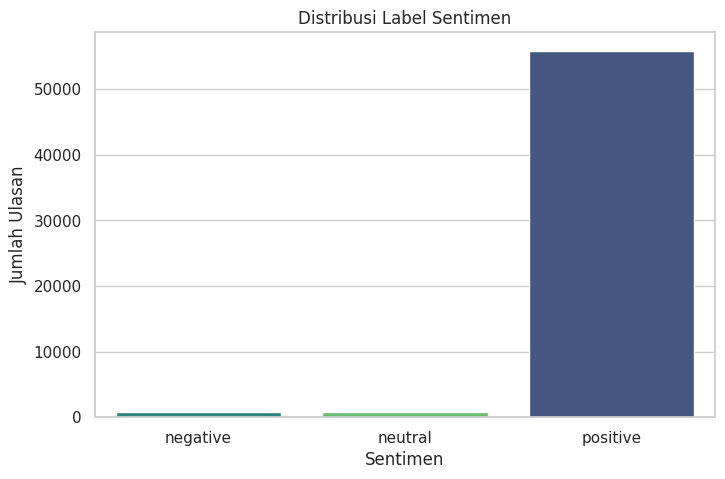

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="sentiment_label",
    order=LABELS,
    hue="sentiment_label",
    palette="viridis",
    legend=False,
)
plt.title("Distribusi Label Sentimen")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Ulasan")
plt.show()

### 3.1 Hubungan rating, sentimen, dan panjang review

In [6]:
eda_data = df.assign(
    rating_numeric=pd.to_numeric(df["rating"], errors="coerce"),
    review_length=df["review_text"].str.split().str.len(),
)

rating_sentiment = pd.crosstab(
    eda_data["rating_numeric"],
    eda_data["sentiment_label"],
    normalize="index",
).reindex(columns=LABELS, fill_value=0)
display(rating_sentiment.style.format("{:.1%}"))

length_summary = eda_data.groupby("sentiment_label")["review_length"].agg(
    ["count", "median", "mean"]
).reindex(LABELS)
display(length_summary.style.format({"median": "{:.1f}", "mean": "{:.1f}"}))

rating_length_correlation = eda_data[["rating_numeric", "review_length"]].corr(
    method="spearman"
).iloc[0, 1]
print(f"Korelasi Spearman rating-panjang review: {rating_length_correlation:.3f}")

inconsistent_mask = (
    (eda_data["rating_numeric"].ge(4) & eda_data["sentiment_label"].eq("negative"))
    | (eda_data["rating_numeric"].le(2) & eda_data["sentiment_label"].eq("positive"))
)
potentially_inconsistent = eda_data.loc[
    inconsistent_mask, ["review_text", "rating", "sentiment_label", "review_length"]
]
print(f"Potensi label tidak konsisten: {len(potentially_inconsistent):,}")
display(potentially_inconsistent.head(10))

sentiment_label,negative,neutral,positive
rating_numeric,,,
1,100.0%,0.0%,0.0%
2,100.0%,0.0%,0.0%
3,0.0%,100.0%,0.0%
4,0.0%,0.0%,100.0%
5,0.0%,0.0%,100.0%


,count,median,mean
sentiment_label,,,
negative,786,15.0,23.3
neutral,778,12.5,17.9
positive,55903,9.0,12.4


Korelasi Spearman rating-panjang review: -0.092
Potensi label tidak konsisten: 0


,review_text,rating,sentiment_label,review_length


### 3.2 Split data

Split dibuat sekali sebelum preprocessing dan balancing. Jika identitas produk tersedia,
produk sama tidak boleh tersebar ke train, validation, dan test set.

In [7]:
def make_data_split(data):
    use_group_split = False
    if group_column:
        groups_per_label = data.groupby("sentiment_label")[group_column].nunique()
        use_group_split = len(groups_per_label) == len(LABELS) and groups_per_label.min() >= 5

    if use_group_split:
        outer_splitter = StratifiedGroupKFold(
            n_splits=5,
            shuffle=True,
            random_state=RANDOM_STATE,
        )
        train_validation_indices, test_indices = next(
            outer_splitter.split(
                data,
                data["sentiment_label"],
                groups=data[group_column],
            )
        )
        train_validation = data.iloc[train_validation_indices]
        test = data.iloc[test_indices]

        inner_splitter = StratifiedGroupKFold(
            n_splits=4,
            shuffle=True,
            random_state=RANDOM_STATE,
        )
        train_indices, validation_indices = next(
            inner_splitter.split(
                train_validation,
                train_validation["sentiment_label"],
                groups=train_validation[group_column],
            )
        )
        train = train_validation.iloc[train_indices]
        validation = train_validation.iloc[validation_indices]
    else:
        train_validation, test = train_test_split(
            data,
            test_size=0.2,
            random_state=RANDOM_STATE,
            stratify=data["sentiment_label"],
        )
        train, validation = train_test_split(
            train_validation,
            test_size=0.25,
            random_state=RANDOM_STATE,
            stratify=train_validation["sentiment_label"],
        )

    parts = tuple(part.reset_index(drop=True) for part in (train, validation, test))
    return (*parts, use_group_split)


train_data, validation_data, test_data, used_group_split = make_data_split(df)

for left, right in [
    (train_data, validation_data),
    (train_data, test_data),
    (validation_data, test_data),
]:
    assert set(left["review_text"]).isdisjoint(right["review_text"])
    if used_group_split:
        assert set(left[group_column]).isdisjoint(right[group_column])

print(f"Strategi split: {'stratified group' if used_group_split else 'stratified'}")
split_summary = pd.DataFrame(
    {
        "jumlah": [len(train_data), len(validation_data), len(test_data)],
        "proporsi": [len(train_data), len(validation_data), len(test_data)],
    },
    index=["train", "validation", "test"],
)
split_summary["proporsi"] /= len(df)
display(split_summary.style.format({"proporsi": "{:.1%}"}))

label_distribution = pd.concat(
    {
        "train": train_data["sentiment_label"].value_counts(normalize=True),
        "validation": validation_data["sentiment_label"].value_counts(normalize=True),
        "test": test_data["sentiment_label"].value_counts(normalize=True),
    },
    axis=1,
).reindex(LABELS)
display(label_distribution.style.format("{:.1%}"))

Strategi split: stratified group


,jumlah,proporsi
train,35007,60.9%
validation,11671,20.3%
test,10789,18.8%


,train,validation,test
sentiment_label,,,
negative,1.3%,1.5%,1.5%
neutral,1.4%,1.3%,1.4%
positive,97.4%,97.2%,97.1%


## 4. Preprocessing teks

In [8]:
NEGATIONS = {"tidak", "bukan", "belum", "kurang", "jangan"}
stop_words = set(StopWordRemoverFactory().get_stop_words()).difference(NEGATIONS)
slang_dict = {
    "bgt": "banget", "bgtt": "banget", "jd": "jadi",
    "ga": "tidak", "gak": "tidak", "gk": "tidak",
    "nggak": "tidak", "ngga": "tidak", "enggak": "tidak",
    "tdk": "tidak", "sdh": "sudah", "udah": "sudah",
    "brg": "barang", "krn": "karena", "cpt": "cepat", "jg": "juga",
    "tp": "tapi", "kalo": "kalau", "dgn": "dengan", "dr": "dari",
    "ori": "original", "mksh": "terima kasih", "tks": "terima kasih",
}


def normalize_slang(text):
    return " ".join(slang_dict.get(word, word) for word in text.split())

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = normalize_slang(text)
    return " ".join(word for word in text.split() if word not in stop_words)

assert NEGATIONS.issubset(set(clean_text("tidak bukan belum kurang jangan bagus").split()))
assert clean_text("nggak bagus") == "tidak bagus"

sample_text = df["review_text"].dropna().iloc[0]
print("Sebelum:", sample_text)
print("Sesudah:", clean_text(sample_text))

Sebelum: baru sekali ini terima brg dr belanja online dg packing super rapih dan aman. semula ragu, bagaimana mungkin mmbeli terlur ayam mentah , sec online. tp ternyata packing liar biasa. rapi, aman. Kerem seller
Sesudah: baru sekali terima barang belanja online dg packing super rapih aman semula ragu bagaimana mungkin mmbeli terlur ayam mentah sec online ternyata packing liar biasa rapi aman kerem seller


In [9]:
stemmer = StemmerFactory().create_stemmer()

def clean_text_advanced(text):
    return stemmer.stem(clean_text(text))

print(f"Sebelum stemming: {sample_text[:50]}...")
print(f"Sesudah stemming: {clean_text_advanced(sample_text)}")


Sebelum stemming: baru sekali ini terima brg dr belanja online dg pa...
Sesudah stemming: baru sekali terima barang belanja online dg packing super rapih aman mula ragu bagaimana mungkin mmbeli terlur ayam mentah sec online nyata packing liar biasa rapi aman rem seller


### 4.1 Normalisasi slang dan emotikon

Bagian ini menambahkan kamus slang dan konversi emotikon untuk meningkatkan kualitas fitur teks.


In [10]:
emoticon_map = {
    "😊": " senang ", "🙂": " senang ", "😄": " senang ", "😍": " suka ",
    "👍": " bagus ", "👌": " bagus ", "⭐": " bintang ",
    "😞": " kecewa ", "😟": " kecewa ", "😠": " marah ", "😡": " marah ",
    "👎": " buruk ", "😢": " sedih ", "😭": " sedih "
}

def convert_emoticons(text):
    for emo, replacement in emoticon_map.items():
        text = text.replace(emo, replacement)
    return text

def clean_text_final(text):
    # Konversi emotikon sebelum regex menghapusnya
    text = convert_emoticons(str(text))
    text = clean_text(text)
    return stemmer.stem(text)

test_slang = "barangnya bgt bagus, tp pengiriman agak lama jd kecewa 😊"
print(f"Original: {test_slang}")
print(f"Processed: {clean_text_final(test_slang)}")

Original: barangnya bgt bagus, tp pengiriman agak lama jd kecewa 😊
Processed: barang banget bagus kirim lama jadi kecewa senang


## 5. Pelatihan model baseline

In [11]:
X_train = train_data["review_text"].apply(clean_text)
y_train = train_data["sentiment_label"]
y_validation = validation_data["sentiment_label"]
y_test = test_data["sentiment_label"]

baseline_tfidf = TfidfVectorizer(max_features=2_000)
X_train_tfidf = baseline_tfidf.fit_transform(X_train)

baseline_model = LogisticRegression(
    max_iter=1_000,
    random_state=RANDOM_STATE,
)
started_at = perf_counter()
baseline_model.fit(X_train_tfidf, y_train)
baseline_training_seconds = perf_counter() - started_at

## 6. Evaluasi model baseline

In [12]:
experiment_results = []


def evaluate_predictions(
    model_name, y_true, y_pred, training_seconds, inference_seconds, split
):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=LABELS,
        average="macro",
        zero_division=0,
    )
    _, recall_per_class, _, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=LABELS,
        zero_division=0,
    )
    result = {
        "model": model_name,
        "split": split,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "neutral_recall": recall_per_class[LABELS.index("neutral")],
        "training_seconds": training_seconds,
        "inference_seconds": inference_seconds,
        "milliseconds_per_review": inference_seconds * 1_000 / len(y_true),
    }
    if split == "validation":
        experiment_results[:] = [
            row for row in experiment_results if row["model"] != model_name
        ]
        experiment_results.append(result)
    print(f"{model_name} | {split} macro F1: {f1:.4f}")
    return result


def macro_f1(y_true, y_pred):
    return precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=LABELS,
        average="macro",
        zero_division=0,
    )[2]


def measure_inference(predictor, raw_texts):
    texts = list(raw_texts)
    predictor(texts[: min(8, len(texts))])
    started_at = perf_counter()
    predictions = np.asarray(predictor(texts))
    duration = perf_counter() - started_at
    return predictions, duration


def plot_confusion(y_true, y_pred, title, cmap="Blues"):
    matrix = confusion_matrix(y_true, y_pred, labels=LABELS)
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap=cmap,
        xticklabels=LABELS,
        yticklabels=LABELS,
    )
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.title(title)
    plt.show()


def predict_baseline(texts):
    cleaned = [clean_text(text) for text in texts]
    return baseline_model.predict(baseline_tfidf.transform(cleaned))


y_pred_baseline_validation, baseline_inference_seconds = measure_inference(
    predict_baseline, validation_data["review_text"]
)
evaluate_predictions(
    "Baseline Logistic Regression",
    y_validation,
    y_pred_baseline_validation,
    baseline_training_seconds,
    baseline_inference_seconds,
    "validation",
)

Baseline Logistic Regression | validation macro F1: 0.4041


{'model': 'Baseline Logistic Regression',
 'split': 'validation',
 'accuracy': 0.9731813897695142,
 'precision_macro': 0.5806014376386021,
 'recall_macro': 0.3776550612045823,
 'f1_macro': 0.4041454337953723,
 'neutral_recall': np.float64(0.013245033112582781),
 'training_seconds': 1.358658570999978,
 'inference_seconds': 1.2451244529999599,
 'milliseconds_per_review': 0.1066853271356319}

## 7. Optimasi hyperparameter

In [13]:
X_train_advanced = train_data["review_text"].apply(clean_text_advanced)

pipeline = Pipeline(
    [
        ("tfidf", TfidfVectorizer()),
        ("clf", LogisticRegression(max_iter=1_000, random_state=RANDOM_STATE)),
    ]
)
param_grid = {
    "tfidf__max_features": [1_000, 2_000, 3_000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__C": [0.1, 1, 10],
}

tuning_cv = (
    StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    if used_group_split
    else StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
)
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=tuning_cv,
    n_jobs=-1,
    scoring="f1_macro",
)
started_at = perf_counter()
fit_kwargs = {"groups": train_data[group_column]} if used_group_split else {}
grid_search.fit(X_train_advanced, y_train, **fit_kwargs)
tuned_training_seconds = perf_counter() - started_at

print(f"Parameter terbaik: {grid_search.best_params_}")
print(f"Skor CV terbaik: {grid_search.best_score_:.4f}")

Parameter terbaik: {'clf__C': 10, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 2)}
Skor CV terbaik: 0.5026


In [14]:
best_model = grid_search.best_estimator_

def predict_tuned(texts):
    return best_model.predict([clean_text_advanced(text) for text in texts])


y_pred_tuned_validation, tuned_inference_seconds = measure_inference(
    predict_tuned, validation_data["review_text"]
)

evaluate_predictions(
    "Tuned Logistic Regression",
    y_validation,
    y_pred_tuned_validation,
    tuned_training_seconds,
    tuned_inference_seconds,
    "validation",
)

Tuned Logistic Regression | validation macro F1: 0.5043


{'model': 'Tuned Logistic Regression',
 'split': 'validation',
 'accuracy': 0.9722388827007111,
 'precision_macro': 0.5864503567641307,
 'recall_macro': 0.4636964186595262,
 'f1_macro': 0.5043488852950861,
 'neutral_recall': np.float64(0.13245033112582782),
 'training_seconds': 83.15263395700003,
 'inference_seconds': 415.75826473899997,
 'milliseconds_per_review': 35.62319122088938}

## 8. Visualisasi kata dominan

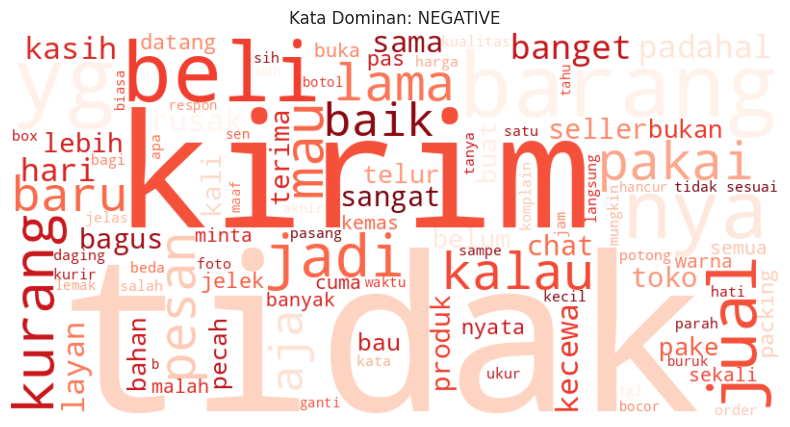

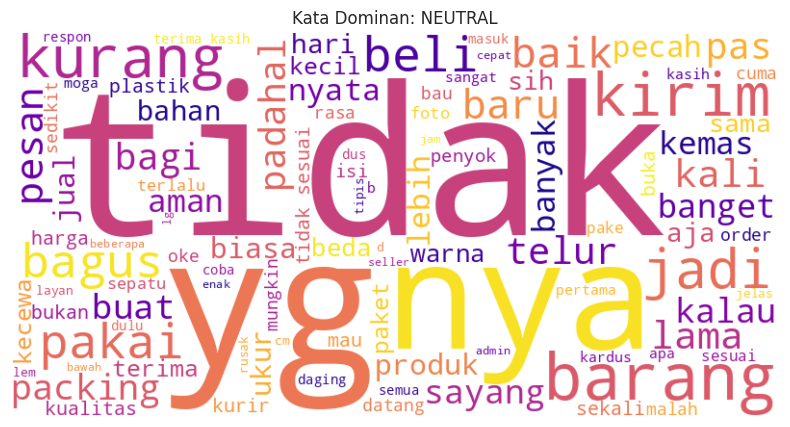

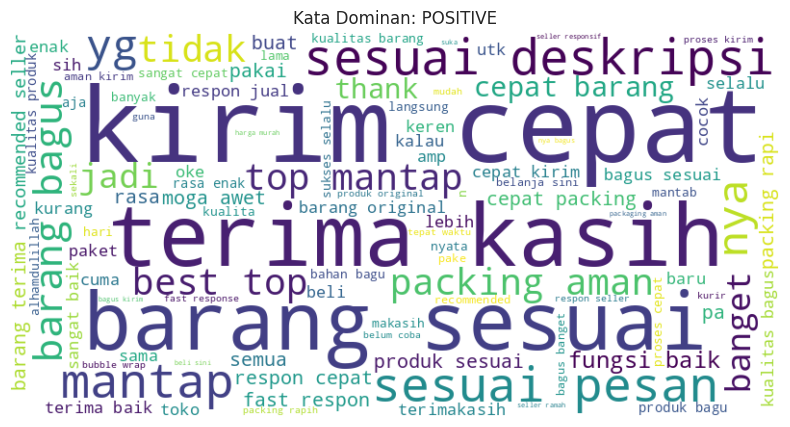

In [15]:
wordcloud_data = train_data.assign(
    clean_text=train_data["review_text"].apply(clean_text_advanced)
)


def show_wordcloud(sentiment, colormap):
    text = " ".join(
        wordcloud_data.loc[
            wordcloud_data["sentiment_label"] == sentiment,
            "clean_text",
        ]
    )
    image = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap=colormap,
        max_words=100,
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(image, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Kata Dominan: {sentiment.upper()}")
    plt.show()


for sentiment, colormap in zip(LABELS, ["Reds", "plasma", "viridis"]):
    show_wordcloud(sentiment, colormap)

## 9. Penanganan ketidakseimbangan kelas

Semua strategi hanya mengubah train set. Held-out test set tetap sama.

### 9.1 Augmentasi teks

In [16]:
synonym_dict = {
    "bagus": ["baik", "oke", "mantap", "keren"],
    "buruk": ["jelek", "kurang", "parah"],
    "kecewa": ["kesal", "nyesel", "sedih"],
    "cepat": ["kilat", "gegas", "ekspres"],
    "lama": ["lambat", "lelet", "telat"],
}


def augment_text(text):
    words = text.split()
    return " ".join(
        random.choice(synonym_dict[word])
        if word in synonym_dict and random.random() > 0.5
        else word
        for word in words
    )


class_counts = train_data["sentiment_label"].value_counts()
target_count = int(class_counts.max())
augmented_parts = [train_data]
for label in LABELS:
    label_rows = train_data[train_data["sentiment_label"] == label]
    required_rows = target_count - len(label_rows)
    if required_rows <= 0:
        continue
    synthetic_rows = label_rows.sample(
        n=required_rows,
        replace=required_rows > len(label_rows),
        random_state=RANDOM_STATE,
    ).copy()
    synthetic_rows["review_text"] = (
        synthetic_rows["review_text"].apply(clean_text).apply(augment_text)
    )
    augmented_parts.append(synthetic_rows)

augmented_train = pd.concat(augmented_parts, ignore_index=True)
augmented_model = Pipeline(
    [
        ("tfidf", TfidfVectorizer(max_features=3_000, ngram_range=(1, 2))),
        ("clf", LogisticRegression(max_iter=1_000, random_state=RANDOM_STATE)),
    ]
)
started_at = perf_counter()
augmented_model.fit(
    augmented_train["review_text"].apply(clean_text_final),
    augmented_train["sentiment_label"],
)
augmented_training_seconds = perf_counter() - started_at

def predict_augmented(texts):
    return augmented_model.predict([clean_text_final(text) for text in texts])


y_pred_augmented_validation, augmented_inference_seconds = measure_inference(
    predict_augmented, validation_data["review_text"]
)
evaluate_predictions(
    "Augmented Logistic Regression",
    y_validation,
    y_pred_augmented_validation,
    augmented_training_seconds,
    augmented_inference_seconds,
    "validation",
)

Augmented Logistic Regression | validation macro F1: 0.5124


{'model': 'Augmented Logistic Regression',
 'split': 'validation',
 'accuracy': 0.9411361494302116,
 'precision_macro': 0.47179772750660987,
 'recall_macro': 0.6192472362840553,
 'f1_macro': 0.512449041238338,
 'neutral_recall': np.float64(0.4370860927152318),
 'training_seconds': 9.820877511999697,
 'inference_seconds': 0.5382384040003672,
 'milliseconds_per_review': 0.0461175909519636}

### 9.2 SMOTE

In [17]:
from imblearn.over_sampling import SMOTE

X_train_smote_text = train_data["review_text"].apply(clean_text_final)

tfidf_smote = TfidfVectorizer(max_features=2_000)
X_train_smote = tfidf_smote.fit_transform(X_train_smote_text)

smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_smote, y_train)

print("Train sebelum SMOTE:", y_train.value_counts().to_dict())
print("Train setelah SMOTE:", pd.Series(y_train_resampled).value_counts().to_dict())

Train sebelum SMOTE: {'positive': 34080, 'neutral': 475, 'negative': 452}
Train setelah SMOTE: {'positive': 34080, 'neutral': 34080, 'negative': 34080}


In [18]:
smote_model = LogisticRegression(
    max_iter=1_000,
    random_state=RANDOM_STATE,
)
started_at = perf_counter()
smote_model.fit(X_train_resampled, y_train_resampled)
smote_training_seconds = perf_counter() - started_at

def predict_smote(texts):
    cleaned = [clean_text_final(text) for text in texts]
    return smote_model.predict(tfidf_smote.transform(cleaned))


y_pred_smote_validation, smote_inference_seconds = measure_inference(
    predict_smote, validation_data["review_text"]
)
evaluate_predictions(
    "SMOTE Logistic Regression",
    y_validation,
    y_pred_smote_validation,
    smote_training_seconds,
    smote_inference_seconds,
    "validation",
)

SMOTE Logistic Regression | validation macro F1: 0.4450


{'model': 'SMOTE Logistic Regression',
 'split': 'validation',
 'accuracy': 0.8908405449404507,
 'precision_macro': 0.4162263015784051,
 'recall_macro': 0.6030127444709009,
 'f1_macro': 0.4449543472450326,
 'neutral_recall': np.float64(0.41721854304635764),
 'training_seconds': 5.024477630999627,
 'inference_seconds': 0.5186793319999197,
 'milliseconds_per_review': 0.044441721531995514}

In [19]:
print("Confusion matrix ditampilkan setelah model final dipilih.")

Confusion matrix ditampilkan setelah model final dipilih.


### 9.3 Class weighting

In [20]:
weighted_model = Pipeline(
    [
        ("tfidf", TfidfVectorizer(max_features=3_000)),
        (
            "clf",
            LogisticRegression(
                max_iter=1_000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
started_at = perf_counter()
weighted_model.fit(X_train, y_train)
weighted_training_seconds = perf_counter() - started_at

def predict_weighted(texts):
    return weighted_model.predict([clean_text(text) for text in texts])


y_pred_weighted_validation, weighted_inference_seconds = measure_inference(
    predict_weighted, validation_data["review_text"]
)
evaluate_predictions(
    "Weighted Logistic Regression",
    y_validation,
    y_pred_weighted_validation,
    weighted_training_seconds,
    weighted_inference_seconds,
    "validation",
)

Weighted Logistic Regression | validation macro F1: 0.4678


{'model': 'Weighted Logistic Regression',
 'split': 'validation',
 'accuracy': 0.910290463542113,
 'precision_macro': 0.4312278260999705,
 'recall_macro': 0.6221669275749075,
 'f1_macro': 0.4677720563598893,
 'neutral_recall': np.float64(0.44370860927152317),
 'training_seconds': 1.382775004999985,
 'inference_seconds': 0.32672026299997015,
 'milliseconds_per_review': 0.027994196127150213}

### 9.4 Peningkatan deteksi kelas netral

Eksperimen menggabungkan fitur panjang teks, train set seimbang, dan penyesuaian
probabilitas untuk memperkuat sinyal kelas `neutral`.

In [21]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import FeatureUnion


n_balanced = train_data["sentiment_label"].value_counts().min()
balanced_train = pd.concat(
    [
        train_data[train_data["sentiment_label"] == label].sample(
            n=n_balanced,
            random_state=RANDOM_STATE,
        )
        for label in LABELS
    ],
    ignore_index=True,
)

X_train_balanced = balanced_train["review_text"].apply(clean_text)
y_train_balanced = balanced_train["sentiment_label"]


class TextStats(BaseEstimator, TransformerMixin):
    def fit(self, texts, labels=None):
        return self

    def transform(self, texts):
        return np.array([len(str(text)) for text in texts]).reshape(-1, 1)


enhanced_pipeline = Pipeline(
    [
        (
            "features",
            FeatureUnion(
                [
                    (
                        "tfidf",
                        TfidfVectorizer(max_features=3_000, ngram_range=(1, 2)),
                    ),
                    (
                        "stats",
                        Pipeline(
                            [("length", TextStats()), ("scale", StandardScaler())]
                        ),
                    ),
                ]
            ),
        ),
        (
            "clf",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1_000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
started_at = perf_counter()
enhanced_pipeline.fit(X_train_balanced, y_train_balanced)
enhanced_training_seconds = perf_counter() - started_at

X_validation_enhanced = validation_data["review_text"].apply(clean_text)
validation_probabilities = enhanced_pipeline.predict_proba(X_validation_enhanced)
neutral_index = list(enhanced_pipeline.classes_).index("neutral")

neutral_bonus_candidates = np.arange(0.0, 0.31, 0.05)
validation_scores = []
for bonus in neutral_bonus_candidates:
    adjusted_probabilities = validation_probabilities.copy()
    adjusted_probabilities[:, neutral_index] += bonus
    validation_predictions = enhanced_pipeline.classes_[
        np.argmax(adjusted_probabilities, axis=1)
    ]
    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_validation,
        validation_predictions,
        labels=LABELS,
        average="macro",
        zero_division=0,
    )
    validation_scores.append(macro_f1)

neutral_bonus = float(neutral_bonus_candidates[np.argmax(validation_scores)])
print(f"Bonus probabilitas neutral terpilih: {neutral_bonus:.2f}")

def predict_enhanced(texts):
    cleaned = [clean_text(text) for text in texts]
    probabilities = enhanced_pipeline.predict_proba(cleaned)
    probabilities[:, neutral_index] += neutral_bonus
    return enhanced_pipeline.classes_[np.argmax(probabilities, axis=1)]


y_pred_enhanced_validation, enhanced_inference_seconds = measure_inference(
    predict_enhanced, validation_data["review_text"]
)

Bonus probabilitas neutral terpilih: 0.00


In [22]:
evaluate_predictions(
    "Enhanced Logistic Regression",
    y_validation,
    y_pred_enhanced_validation,
    enhanced_training_seconds,
    enhanced_inference_seconds,
    "validation",
)

Enhanced Logistic Regression | validation macro F1: 0.3985


{'model': 'Enhanced Logistic Regression',
 'split': 'validation',
 'accuracy': 0.797189615285751,
 'precision_macro': 0.392605820595642,
 'recall_macro': 0.6609032104024731,
 'f1_macro': 0.3985137008376463,
 'neutral_recall': np.float64(0.5761589403973509),
 'training_seconds': 0.1874770209997223,
 'inference_seconds': 0.34628880099990056,
 'milliseconds_per_review': 0.02967087661724793}

In [23]:
positive_as_neutral_mask = (
    (y_validation.to_numpy() == "positive")
    & (np.asarray(y_pred_enhanced_validation) == "neutral")
)
positive_as_neutral = validation_data.loc[
    positive_as_neutral_mask,
    ["review_text", "sentiment_label"],
].reset_index(drop=True)

print(f"Total positive diprediksi neutral: {len(positive_as_neutral)}")
display(positive_as_neutral.head(10))

Total positive diprediksi neutral: 1580


,review_text,sentiment_label
0,"Belum dicoba, masih simpan kulkas. Packing bag...",positive
1,"Pros: Telurnya segar, warna kuningnya orange, ...",positive
2,"Kemasan aman, rapih, telur tidak ada yang pecah",positive
3,Kirain bakal po sampe berbulan2 dibawa santai ...,positive
4,telornya kecil kecil kotor lg dijaga kwalitasn...,positive
5,"Telur sampai dengan aman, ga ada yg pecah. Tel...",positive
6,Dapat hadiah ini dari pembelian varian berry b...,positive
7,"dapet gratis yang rasa vanilla,,",positive
8,"isinya enak banget, rotinya lembut, sayang bag...",positive
9,"packing aman, enaaaak, empuk, baru pertama kal...",positive


## 10. Eksperimen IndoBERT

Bagian opsional ini memakai `indobenchmark/indobert-base-p2`. Jalankan dengan runtime
GPU agar fine-tuning lebih cepat.

In [24]:
if RUN_INDOBERT:
    from collections import Counter
    from glob import glob

    import torch
    from datasets import Dataset
    from transformers import (
        AutoModelForSequenceClassification,
        AutoTokenizer,
        Trainer,
        TrainingArguments,
    )

    torch.manual_seed(RANDOM_STATE)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_STATE)

    BERT_MODEL_NAME = "indobenchmark/indobert-base-p2"
    tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
    label2id = {label: index for index, label in enumerate(LABELS)}
    id2label = {index: label for index, label in enumerate(LABELS)}
    bert_model = AutoModelForSequenceClassification.from_pretrained(
        BERT_MODEL_NAME,
        num_labels=len(LABELS),
        id2label=id2label,
        label2id=label2id,
    )

    def tokenize_function(examples):
        return tokenizer(
            examples["review_text"],
            padding="max_length",
            truncation=True,
            max_length=128,
        )
else:
    print("IndoBERT dilewati. Set RUN_INDOBERT=True untuk menjalankannya.")

IndoBERT dilewati. Set RUN_INDOBERT=True untuk menjalankannya.


### 10.1 Menyiapkan dataset

In [25]:
if RUN_INDOBERT:
    train_dataset = Dataset.from_pandas(
        train_data[["review_text", "sentiment_label"]], preserve_index=False
    )
    validation_dataset = Dataset.from_pandas(
        validation_data[["review_text", "sentiment_label"]], preserve_index=False
    )

    def add_label(row):
        return {"labels": label2id[row["sentiment_label"]]}

    train_dataset = train_dataset.map(add_label).map(tokenize_function, batched=True)
    validation_dataset = validation_dataset.map(add_label).map(
        tokenize_function, batched=True
    )

### 10.2 Fine-tuning

In [26]:
if RUN_INDOBERT:
    def compute_metrics(prediction):
        labels = prediction.label_ids
        predictions = prediction.predictions.argmax(axis=-1)
        return {"f1": macro_f1(labels, predictions)}

    training_args = TrainingArguments(
        output_dir="results",
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        warmup_steps=100,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        save_total_limit=1,
        logging_steps=10,
        disable_tqdm=True,
        report_to="none",
        seed=RANDOM_STATE,
        data_seed=RANDOM_STATE,
    )
    trainer = Trainer(
        model=bert_model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=validation_dataset,
        compute_metrics=compute_metrics,
    )
    started_at = perf_counter()
    trainer.train()
    bert_training_seconds = perf_counter() - started_at

### 10.3 Evaluasi IndoBERT

In [27]:
if RUN_INDOBERT:
    def predict_indobert(texts):
        raw_dataset = Dataset.from_dict({"review_text": list(texts)})
        tokenized_dataset = raw_dataset.map(tokenize_function, batched=True)
        output = trainer.predict(tokenized_dataset)
        return np.array(
            [id2label[index] for index in output.predictions.argmax(axis=-1)]
        )

    y_pred_bert_validation, bert_inference_seconds = measure_inference(
        predict_indobert, validation_data["review_text"]
    )
    evaluate_predictions(
        "IndoBERT",
        y_validation,
        y_pred_bert_validation,
        bert_training_seconds,
        bert_inference_seconds,
        "validation",
    )

In [28]:
if RUN_INDOBERT:
    print("IndoBERT selesai dievaluasi pada validation set.")

### 10.4 Analisis kesalahan

In [29]:
if RUN_INDOBERT:
    error_indices = np.where(y_pred_bert_validation != y_validation.to_numpy())[0]
    error_samples = pd.DataFrame(
        {
            "Ulasan": validation_data.iloc[error_indices[:10]]["review_text"].to_numpy(),
            "Aktual": y_validation.iloc[error_indices[:10]].to_numpy(),
            "Prediksi": y_pred_bert_validation[error_indices[:10]],
        }
    )
    display(error_samples)

### 10.5 Visualisasi bobot attention

In [30]:
if RUN_INDOBERT:
    checkpoints = glob("results/checkpoint-*")
    last_checkpoint = (
        max(checkpoints, key=os.path.getctime) if checkpoints else BERT_MODEL_NAME
    )
    print(f"Memuat model dari: {last_checkpoint}")

    attention_model = AutoModelForSequenceClassification.from_pretrained(
        last_checkpoint,
        num_labels=len(LABELS),
        id2label=id2label,
        label2id=label2id,
        attn_implementation="eager",
    ).to(trainer.args.device)


    def visualize_attention(text):
        inputs = tokenizer(
            text,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=128,
        ).to(attention_model.device)

        with torch.no_grad():
            outputs = attention_model(**inputs, output_attentions=True)

        attention = outputs.attentions[-1][0, 0].cpu().numpy()
        tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

        plt.figure(figsize=(10, 8))
        sns.heatmap(
            attention[: len(tokens), : len(tokens)],
            xticklabels=tokens,
            yticklabels=tokens,
            cmap="YlGnBu",
        )
        plt.title(f"Attention Map\nUlasan: {text[:50]!r}")
        plt.xticks(rotation=45)
        plt.show()


    sample_review = "barangnya rusak parah dan pengiriman sangat lambat"
    visualize_attention(sample_review)


### 10.6 Perbandingan model

Semua skor perbandingan berasal dari validation set. Test set belum disentuh.

,split,accuracy,precision_macro,recall_macro,f1_macro,neutral_recall,training_seconds,inference_seconds,milliseconds_per_review
model,,,,,,,,,
Augmented Logistic Regression,validation,94.11%,47.18%,61.92%,51.24%,43.71%,9.82,0.5382,0.046
Tuned Logistic Regression,validation,97.22%,58.65%,46.37%,50.43%,13.25%,83.15,415.7583,35.623
Weighted Logistic Regression,validation,91.03%,43.12%,62.22%,46.78%,44.37%,1.38,0.3267,0.028
SMOTE Logistic Regression,validation,89.08%,41.62%,60.30%,44.50%,41.72%,5.02,0.5187,0.044
Baseline Logistic Regression,validation,97.32%,58.06%,37.77%,40.41%,1.32%,1.36,1.2451,0.107
Enhanced Logistic Regression,validation,79.72%,39.26%,66.09%,39.85%,57.62%,0.19,0.3463,0.030


Model final berdasarkan validation macro F1: Augmented Logistic Regression
Augmented Logistic Regression | test macro F1: 0.5354


,split,accuracy,precision_macro,recall_macro,f1_macro,neutral_recall,training_seconds,inference_seconds,milliseconds_per_review
model,,,,,,,,,
Augmented Logistic Regression,test,0.938827,0.488327,0.653309,0.535393,0.414474,9.820878,331.317823,30.708854


              precision    recall  f1-score   support

    negative       0.34      0.59      0.43       160
     neutral       0.14      0.41      0.21       152
    positive       0.99      0.95      0.97     10477

    accuracy                           0.94     10789
   macro avg       0.49      0.65      0.54     10789
weighted avg       0.97      0.94      0.95     10789



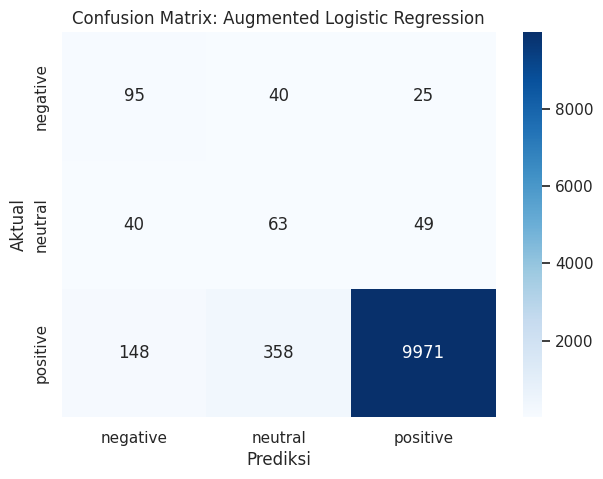

In [31]:
comparison_df = (
    pd.DataFrame(experiment_results)
    .set_index("model")
    .sort_values("f1_macro", ascending=False)
)

metric_columns = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "neutral_recall",
]
display(
    comparison_df.style.format(
        {
            **{column: "{:.2%}" for column in metric_columns},
            "training_seconds": "{:.2f}",
            "inference_seconds": "{:.4f}",
            "milliseconds_per_review": "{:.3f}",
        }
    )
)

final_model_name = comparison_df["f1_macro"].idxmax()
print(f"Model final berdasarkan validation macro F1: {final_model_name}")

model_predictors = {
    "Baseline Logistic Regression": predict_baseline,
    "Tuned Logistic Regression": predict_tuned,
    "Augmented Logistic Regression": predict_augmented,
    "SMOTE Logistic Regression": predict_smote,
    "Weighted Logistic Regression": predict_weighted,
    "Enhanced Logistic Regression": predict_enhanced,
}
if RUN_INDOBERT:
    model_predictors["IndoBERT"] = predict_indobert

y_pred_final, final_inference_seconds = measure_inference(
    model_predictors[final_model_name], test_data["review_text"]
)
final_result = evaluate_predictions(
    final_model_name,
    y_test,
    y_pred_final,
    comparison_df.loc[final_model_name, "training_seconds"],
    final_inference_seconds,
    "test",
)
display(pd.DataFrame([final_result]).set_index("model"))
print(classification_report(y_test, y_pred_final, labels=LABELS, zero_division=0))
plot_confusion(y_test, y_pred_final, f"Confusion Matrix: {final_model_name}")

### 10.7 Pengujian IndoBERT pada salah klasifikasi positif sebagai netral

IndoBERT diuji pada review positif di validation set yang diprediksi sebagai kelas
`neutral` oleh Enhanced Logistic Regression.

In [32]:
if RUN_INDOBERT:
    misclassified_texts = positive_as_neutral["review_text"].tolist()
    if not misclassified_texts:
        print("Tidak ada kasus positive-as-neutral untuk diuji.")
    else:
        y_pred_bert_labels = predict_indobert(misclassified_texts)
        counts = Counter(y_pred_bert_labels)
        print(f"Total sampel diuji: {len(misclassified_texts)}")
        print("Hasil prediksi IndoBERT:")
        for label, count in counts.items():
            print(f"- {label}: {count} ({count / len(misclassified_texts):.2%})")
        corrected = [
            text
            for text, label in zip(misclassified_texts, y_pred_bert_labels)
            if label == "positive"
        ][:5]
        print("\nContoh ulasan yang diperbaiki IndoBERT:")
        for text in corrected:
            print(f"Ulasan: {text}")
else:
    print("Analisis IndoBERT dilewati.")

Analisis IndoBERT dilewati.


## 11. Prediksi ulasan baru

Fungsi memakai model yang dipilih dari validation set.

In [33]:
def prediksi_sentimen(teks):
    return model_predictors[final_model_name]([teks])[0]


contoh_ulasan = [
    "Produknya bagus banget dan pengiriman cepat",
    "Barang rusak dan penjual tidak responsif",
    "Produknya cukup, tidak buruk tapi juga tidak istimewa",
]
for ulasan in contoh_ulasan:
    print(f"{ulasan!r} -> {prediksi_sentimen(ulasan)}")

'Produknya bagus banget dan pengiriman cepat' -> positive
'Barang rusak dan penjual tidak responsif' -> negative
'Produknya cukup, tidak buruk tapi juga tidak istimewa' -> negative


## 12. Kesimpulan

Pemilihan model memakai macro F1 agar seluruh kelas mendapat bobot setara. Recall kelas
`neutral` dilaporkan terpisah karena kelas ini menjadi fokus kesalahan utama.

In [34]:
winner = comparison_df.loc[final_model_name]
print(f"Model terbaik: {final_model_name}")
print(f"Validation macro F1: {winner['f1_macro']:.2%}")
print(f"Held-out test macro F1: {final_result['f1_macro']:.2%}")
print(f"Recall neutral test: {final_result['neutral_recall']:.2%}")
print(f"Waktu training: {winner['training_seconds']:.2f} detik")
print(f"Waktu inference test set: {final_result['inference_seconds']:.4f} detik")

print("\nKeterbatasan:")
print("- Data berasal dari satu dataset Tokopedia 2025.")
print("- Normalisasi slang dan augmentasi masih berbasis kamus kecil.")
print("- Group split hanya aktif bila identitas produk tersedia dan memadai.")
print("- Kandidat threshold neutral masih dibatasi pada rentang 0.00-0.30.")

print("\nRekomendasi:")
print("- Tambah data lintas kategori dan periode.")
print("- Tuning threshold hanya pada validation set.")
print("- Uji stabilitas hasil pada beberapa random seed.")

Model terbaik: Augmented Logistic Regression
Validation macro F1: 51.24%
Held-out test macro F1: 53.54%
Recall neutral test: 41.45%
Waktu training: 9.82 detik
Waktu inference test set: 331.3178 detik

Keterbatasan:
- Data berasal dari satu dataset Tokopedia 2025.
- Normalisasi slang dan augmentasi masih berbasis kamus kecil.
- Group split hanya aktif bila identitas produk tersedia dan memadai.
- Kandidat threshold neutral masih dibatasi pada rentang 0.00-0.30.

Rekomendasi:
- Tambah data lintas kategori dan periode.
- Tuning threshold hanya pada validation set.
- Uji stabilitas hasil pada beberapa random seed.
